# Sign Language Logistic Regression with NumPy

## Project Overview

This project implements a **multinomial logistic regression model from scratch using NumPy** for classifying images from the Sign Language MNIST dataset.

The dataset contains grayscale images of hand signs representing letters of the American Sign Language alphabet. Each image is represented by 784 pixel values, while the corresponding label identifies the represented letter.

The project covers the complete machine learning pipeline, including:

- loading and exploring the dataset;
- preprocessing and normalization of image data;
- label encoding and one-hot encoding;
- multinomial logistic regression;
- softmax activation;
- cross-entropy loss with L2 regularization;
- gradient computation;
- gradient descent optimization;
- model evaluation using accuracy;
- confusion matrix visualization.

The implementation relies primarily on **NumPy** and uses vectorized operations wherever possible.

## Implementation Notes

- The logistic regression model is implemented from scratch without using a machine learning library for training.
- Matrix operations are vectorized using NumPy.
- Type annotations are used throughout the implementation to improve code clarity and maintainability.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.figure import Figure
from sklearn.metrics import confusion_matrix

plt.rc("font", size=18)

## 1. Dataset Loading

In [3]:
TRAIN_SHAPE: tuple[int, int] = (27455, 785)
TEST_SHAPE: tuple[int, int] = (7172, 785)

train_path: str = "./data/sign_mnist_train.csv"
test_path: str = "./data/sign_mnist_test.csv"

train_data: pd.DataFrame = pd.read_csv(train_path)
test_data: pd.DataFrame = pd.read_csv(test_path)

assert train_data.shape == TRAIN_SHAPE, (
    f"Unexpected training data shape: {train_data.shape}"
)
assert test_data.shape == TEST_SHAPE, (
    f"Unexpected test data shape: {test_data.shape}"
)

train_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


Number of classes: 24


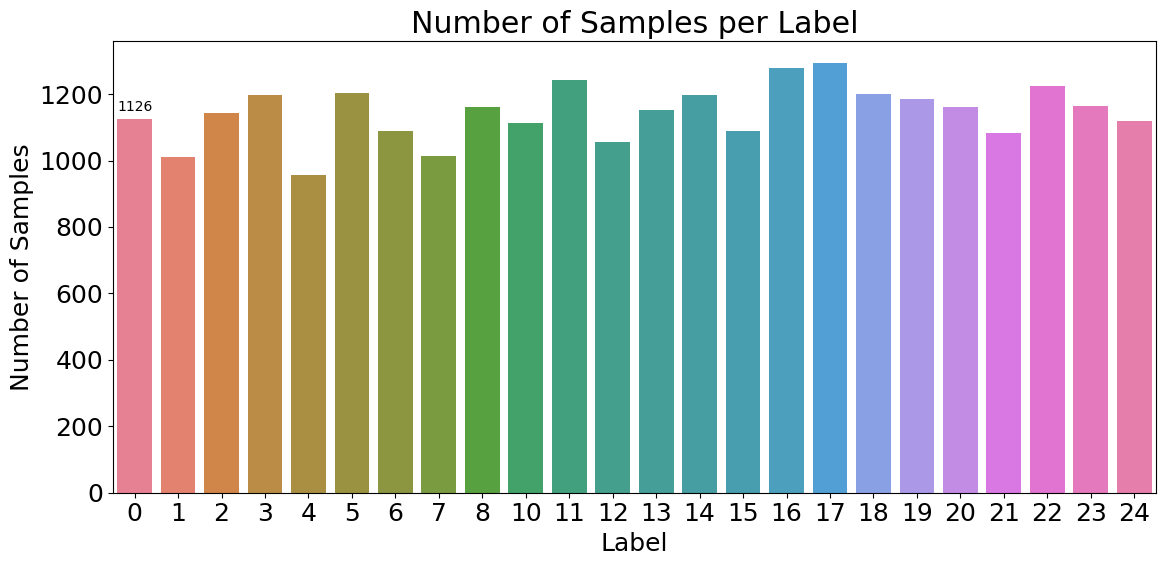

In [4]:
num_classes: int = train_data["label"].nunique()

print(f"Number of classes: {num_classes}")

palette: list = sns.color_palette("husl", num_classes)

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    x="label",
    data=train_data,
    hue="label",
    palette=palette,
    legend=False,
)

ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=10)

plt.title("Number of Samples per Label")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

### Feature and Label Separation

The first column contains the class labels, while the remaining 784 columns contain the pixel values of each image.

The features and labels are separated for both the training and test datasets.

In [5]:
train_x: np.ndarray = train_data.iloc[:, 1:].to_numpy()
train_y: np.ndarray = train_data.iloc[:, 0].to_numpy()

test_x: np.ndarray = test_data.iloc[:, 1:].to_numpy()
test_y: np.ndarray = test_data.iloc[:, 0].to_numpy()

assert train_x.shape == (27455, 784)
assert train_y.shape == (27455,)
assert test_x.shape == (7172, 784)
assert test_y.shape == (7172,)

### Mapping Labels to Letters

In [6]:
labels_map: dict[int, str] = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I',
    10: 'K', 11: 'L', 12: 'M', 13: 'N',
    14: 'O', 15: 'P', 16: 'Q', 17: 'R',
    18: 'S', 19: 'T', 20: 'U', 21: 'V',
    22: 'W', 23: 'X', 24: 'Y'
}


### Sample Visualization

The following visualization shows the first 16 images from the training dataset.

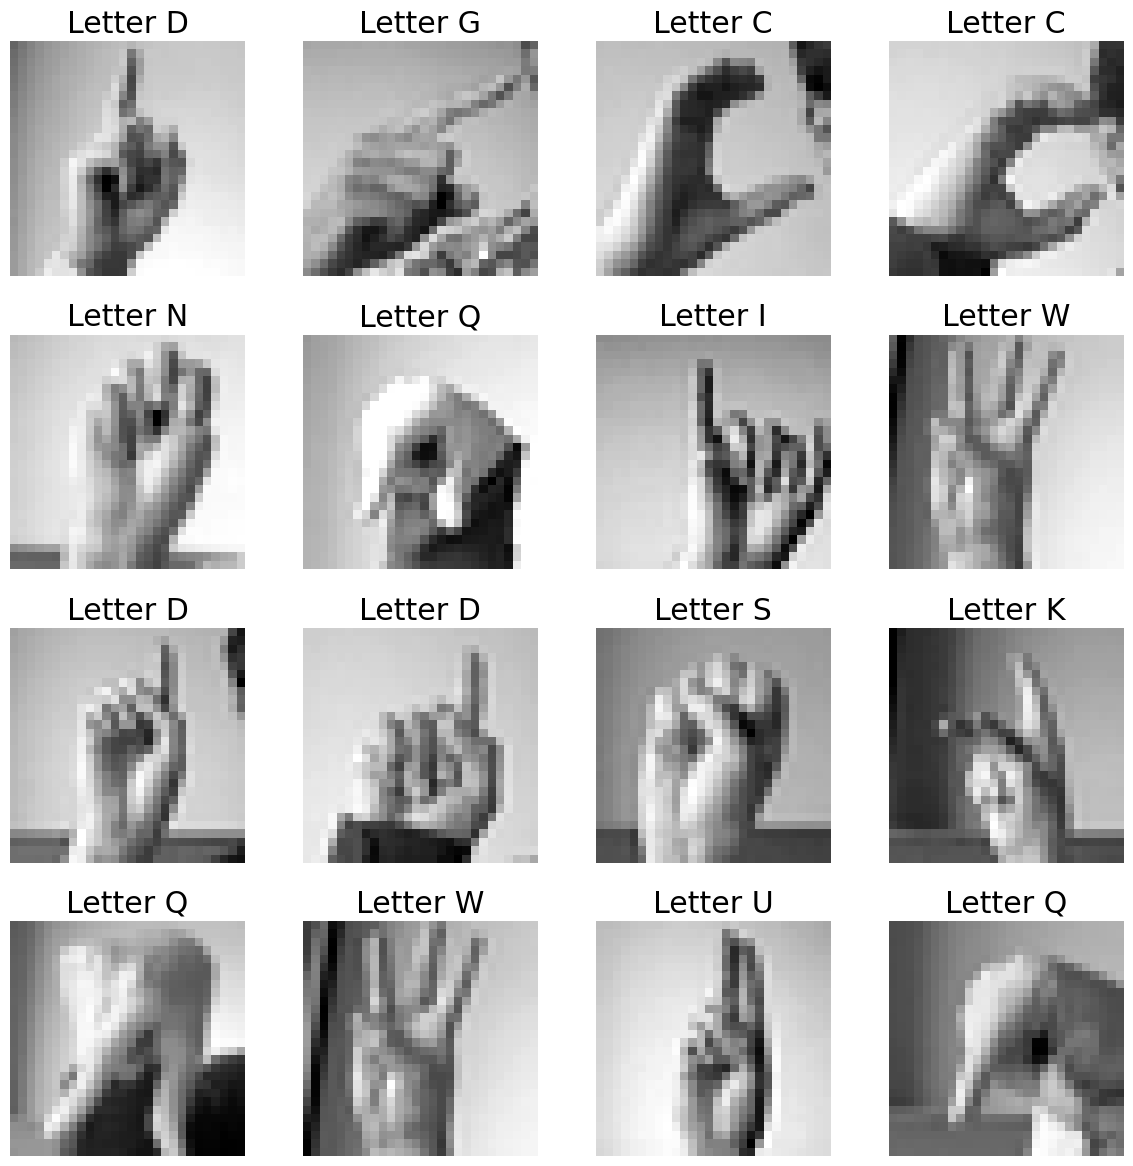

In [7]:
def show_samples(x_set: np.ndarray, y_set: np.ndarray) -> None:
    """Display a set of images with their corresponding letters."""

    size: int = x_set.shape[0]

    fig: Figure
    axes: np.ndarray
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))

    for index in range(size):
        row: int = index // 4
        col: int = index % 4

        image: np.ndarray = x_set[index].reshape(28, 28)

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(f"Letter {labels_map[y_set[index]]}")
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_x[:16], train_y[:16])

### Relabeling Class Labels

In [8]:
print("Original label distribution:")
print(pd.Series(train_y).value_counts().sort_index())

print("\nThe letters J and Z are not included because they require hand movement")
print("and cannot be represented by static images.")
print("Relabeling the classes to consecutive values from 0 to 23:")

new_labels: dict[int, int] = {
    label: index
    for index, label in enumerate(labels_map.keys())
}

print("Label mapping:")
print(new_labels)

train_y: np.ndarray = np.array([
    new_labels[label]
    for label in train_y
])

test_y: np.ndarray = np.array([
    new_labels[label]
    for label in test_y
])

print("Relabeled train labels shape:", train_y.shape)
print("Relabeled test labels shape:", test_y.shape)

assert train_y.min() == 0
assert train_y.max() == 23
assert test_y.min() == 0
assert test_y.max() == 23

Original label distribution:
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

The letters J and Z are not included because they require hand movement
and cannot be represented by static images.
Relabeling the classes to consecutive values from 0 to 23:
Label mapping:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23}
Relabeled train labels shape: (27455,)
Relabeled test labels shape: (7172,)


## Multinomial Logistic Regression

In this section, we implement a multinomial logistic regression model using NumPy for the classification of sign language letters.

The following function adds a column of ones to a matrix, allowing us to represent the weight corresponding to the bias term, similarly to what we did for linear regression.

In [9]:
def augment_matrix(x: np.ndarray) -> np.ndarray:
    """
    Add a column of ones to the feature matrix to account for the bias term.

    Args:
        x: Feature matrix of shape (m, n).

    Returns:
        Augmented feature matrix of shape (m, n + 1).
    """
    column_ones: np.ndarray = np.ones((x.shape[0], 1))
    return np.hstack((column_ones, x))

### Feature Normalization

The following function normalizes pixel values to the [0, 1] interval.

Since the input features represent pixel intensities with values between 0 and 255, normalization is performed by dividing each feature by 255.

In [10]:
def normalize(x: np.ndarray) -> np.ndarray:
    """
    Normalize pixel values to the [0, 1] interval.

    Args:
        x: Feature matrix containing pixel intensities.

    Returns:
        A normalized matrix with values between 0 and 1.
    """
    return x / 255.0


train_x_ext: np.ndarray = augment_matrix(normalize(train_x))
test_x_ext: np.ndarray = augment_matrix(normalize(test_x))

assert train_x_ext.shape == (27455, 785)
assert test_x_ext.shape == (7172, 785)

assert np.all(train_x_ext[:, 0] == 1)
assert np.all(test_x_ext[:, 0] == 1)

assert np.all(train_x_ext >= 0)
assert np.all(test_x_ext >= 0)
assert np.all(train_x_ext <= 1)
assert np.all(test_x_ext <= 1)

### One-Hot Encoding

We encode each class label using one-hot encoding. Each class is represented by a k-dimensional binary vector, where k is the number of classes.

In our dataset, k = 24. The vector contains zeros everywhere except at the position corresponding to the class label, where the value is 1.

For example:

- 4 becomes `[0 0 0 0 1 0 ... 0]`
- 0 becomes `[1 0 0 0 0 0 ... 0]`

In [11]:
k: int = num_classes

print(f"Number of classes: {k}")


def one_hot(val: int, classes: int) -> np.ndarray:
    """
    Convert an integer class label into a one-hot encoded vector.

    Args:
        val: Class label, an integer between 0 and classes - 1.
        classes: Number of classes.

    Returns:
        A binary array of shape (1, classes), with 1 at position val.
    """
    assert 0 <= val < classes, (
        f"Value {val} is not between 0 and {classes - 1}"
    )

    result: np.ndarray = np.zeros((1, classes))
    result[0, val] = 1

    assert result.shape == (1, classes)

    return result


# Test one-hot encoding

assert np.all(
    one_hot(7, k)
    == np.array([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
                  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
)

assert np.all(
    one_hot(3, k)
    == np.array([[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                  0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
)


train_y_all: np.ndarray = np.concatenate(
    [one_hot(int(label), k) for label in train_y]
)

test_y_all: np.ndarray = np.concatenate(
    [one_hot(int(label), k) for label in test_y]
)


assert train_y_all.shape == (27455, 24)
assert test_y_all.shape == (7172, 24)

assert np.all((train_y_all == 0) | (train_y_all == 1))
assert np.all((test_y_all == 0) | (test_y_all == 1))

Number of classes: 24


### Softmax Function

When multiplying the feature matrix \(X\), of shape \((m, n)\), by the parameter matrix \(\theta\), of shape \((n, k)\), we obtain \(X\theta\), of shape \((m, k)\), where:

- \(m\) = number of samples (images)
- \(n\) = number of features
- \(k\) = number of classes

The `softmax()` function returns a matrix of shape \((m, k)\), where the probabilities for each sample sum to 1.

The softmax function can be written compactly as:

$$
\operatorname{softmax}(X, \theta)
=
\frac{e^{X\theta}}
{e^{X\theta}\mathbb{1}_k}
$$

The denominator \(e^{X\theta}\mathbb{1}_k\) is a vector of shape \((m, 1)\), obtained by summing the values on each row. The division is performed using NumPy broadcasting.

In [12]:
# Check the dimensions of X @ theta

m: int
n: int
m, n = train_x_ext.shape

np.random.seed(11)
theta: np.ndarray = np.random.randn(n, k)

assert (train_x_ext @ theta).shape == (m, k)

In [13]:
def softmax(x: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """
    Compute the softmax probabilities.

    Args:
        x: Feature matrix of shape (m, n).
        theta: Parameter matrix of shape (n, k).

    Returns:
        Softmax probability matrix of shape (m, k).
    """
    assert x.shape[1] == theta.shape[0]

    scores: np.ndarray = x @ theta

    # Subtract the maximum value from each row for numerical stability.
    exp_scores: np.ndarray = np.exp(
        scores - np.max(scores, axis=1, keepdims=True)
    )

    exp_sum: np.ndarray = np.sum(exp_scores, axis=1, keepdims=True)

    return exp_scores / exp_sum

In [14]:
m: int
n: int
m, n = train_x_ext.shape

np.random.seed(11)
theta: np.ndarray = np.random.randn(n, k)

smax: np.ndarray = softmax(train_x_ext, theta)

assert smax.shape == (m, k)
assert np.all(np.abs(smax.sum(axis=1) - 1) < 1e-12)

### Cost Function with Regularization

The cost function for multinomial logistic regression, including L2 regularization, can be written compactly as:

$$
J(\theta, \lambda)
=
-\frac{1}{m}
\mathbf{1}_m^T
\left\{
Y \odot
\log[\operatorname{softmax}(X\theta)]
\mathbf{1}_k
\right\}
+
\frac{\lambda}{2}
\|\Theta[1:, :]\|_F^2
$$

where:

- \(m\) is the number of samples;
- \(n\) is the number of features;
- \(k\) is the number of classes;
- \(Y\) contains the one-hot encoded labels;
- \(\lambda\) is the regularization parameter;
- \(\odot\) denotes element-wise multiplication.

The L2 regularization term excludes the first row of \(\theta\), corresponding to the bias term.

For a matrix \(A\), the Frobenius norm is defined as:

$$
\|A\|_F =
\sqrt{
\sum_{i=0}^{m-1}
\sum_{j=0}^{n-1}
|a_{ij}|^2
}
$$

In [15]:
def cost(
    x: np.ndarray,
    y: np.ndarray,
    theta: np.ndarray,
    lmbda: float
) -> np.ndarray:
    """
    Compute the regularized cost function.

    Args:
        x: Feature matrix of shape (m, n).
        y: One-hot encoded labels of shape (m, k).
        theta: Parameter matrix of shape (n, k).
        lmbda: Regularization parameter.

    Returns:
        The cost as a scalar array.
    """
    m: int = x.shape[0]

    one_m: np.ndarray = np.ones((m, 1))
    one_k: np.ndarray = np.ones((k, 1))

    y_hat: np.ndarray = softmax(x, theta)

    term1: np.ndarray = (
        (-1 / m)
        * (one_m.T @ (y * np.log(y_hat) @ one_k))
    )

    # Exclude the bias row from regularization.
    term2: np.ndarray = (lmbda / 2) * np.sum(theta[1:, :] ** 2)

    return (term1 + term2).flatten()

In [16]:
m: int
n: int
m, n = train_x_ext.shape

np.random.seed(11)
theta: np.ndarray = np.random.randn(n, k)

result: np.ndarray = cost(
    train_x_ext,
    train_y_all,
    theta=theta,
    lmbda=0.2
)

assert result.shape == (1,)
assert np.isfinite(result).all()
assert result[0] >= 0

### Gradient

The gradient of the regularized cost function is given by:

$$
\nabla_{\theta} J =
-\frac{1}{m}X^T
\left[
Y-\operatorname{softmax}(X\theta)
\right]
+
\lambda
\left[
\begin{array}{c}
0 \\
\theta_{1:}
\end{array}
\right]
$$

The regularization matrix has the same shape as \(\theta\), namely \((n,k)\), but its first row is zero. This excludes the bias term from regularization.

In [17]:
def deltas(
    x: np.ndarray,
    y: np.ndarray,
    theta: np.ndarray,
    lmbda: float
) -> np.ndarray:
    """
    Compute the gradient of the regularized cost function.

    Args:
        x: Feature matrix of shape (m, n).
        y: One-hot encoded labels of shape (m, k).
        theta: Parameter matrix of shape (n, k).
        lmbda: Regularization parameter.

    Returns:
        Gradient matrix with the same shape as theta, (n, k).
    """
    m: int = x.shape[0]

    y_hat: np.ndarray = softmax(x, theta)

    theta_reg: np.ndarray = theta.copy()
    theta_reg[0, :] = 0

    return (-1 / m) * (x.T @ (y - y_hat)) + lmbda * theta_reg

In [18]:
m: int
n: int
m, n = train_x_ext.shape

np.random.seed(11)
theta: np.ndarray = np.random.randn(n, k)

grad: np.ndarray = deltas(
    train_x_ext,
    train_y_all,
    theta=theta,
    lmbda=0.2
)

assert grad.shape == (n, k)
assert np.isfinite(grad).all()

### Model Accuracy

We calculate the model accuracy by comparing the predicted class with the actual class for each sample.

The predicted class is the class with the highest probability returned by the softmax function.

In [19]:
def calculate_accuracy(
    set_x: np.ndarray,
    set_y: np.ndarray,
    theta: np.ndarray
) -> float:
    """
    Calculate the classification accuracy.

    Args:
        set_x: Feature matrix of shape (m, n).
        set_y: One-hot encoded labels of shape (m, k).
        theta: Parameter matrix of shape (n, k).

    Returns:
        Classification accuracy as a percentage.
    """
    y_hat: np.ndarray = softmax(set_x, theta)

    predicted: np.ndarray = np.argmax(y_hat, axis=1)
    actual: np.ndarray = np.argmax(set_y, axis=1)

    return np.mean(predicted == actual) * 100.0

### Model Training

We train the multinomial logistic regression model using gradient descent.

At each epoch, the parameters are updated using the gradient of the regularized cost function:

$$
\theta \leftarrow \theta - \alpha \nabla_\theta J
$$

where \(\alpha\) is the learning rate.

In [20]:
lmbda: float = 0.05
alpha: float = 0.1

m: int
n: int
m, n = train_x_ext.shape

np.random.seed(11)
theta: np.ndarray = np.random.randn(n, k)

epochs: int = 500

values: list[np.ndarray] = []
accuracies: list[float] = []

for epoch in range(epochs):
    theta -= alpha * deltas(
        train_x_ext,
        train_y_all,
        theta,
        lmbda
    )

    if epoch % 10 == 0:
        values.append(
            cost(
                train_x_ext,
                train_y_all,
                theta,
                lmbda
            )
        )

        accuracies.append(
            calculate_accuracy(
                test_x_ext,
                test_y_all,
                theta
            )
        )

        print(
            f"Epoch: {epoch} | "
            f"Cost: {values[-1][0]:.6f} | "
            f"Accuracy: {accuracies[-1]:.2f}%"
        )

    lmbda *= 0.9

print(f"Last cost: {values[-1][0]:.6f}")

Epoch: 0 | Cost: 488.450428 | Accuracy: 4.89%
Epoch: 10 | Cost: 160.615006 | Accuracy: 4.48%
Epoch: 20 | Cost: 59.623642 | Accuracy: 4.14%
Epoch: 30 | Cost: 25.360267 | Accuracy: 4.27%
Epoch: 40 | Cost: 13.398511 | Accuracy: 4.38%
Epoch: 50 | Cost: 9.114186 | Accuracy: 4.52%
Epoch: 60 | Cost: 7.499378 | Accuracy: 4.75%
Epoch: 70 | Cost: 6.819465 | Accuracy: 5.41%
Epoch: 80 | Cost: 6.470946 | Accuracy: 5.74%
Epoch: 90 | Cost: 6.243288 | Accuracy: 6.19%
Epoch: 100 | Cost: 6.062761 | Accuracy: 6.53%
Epoch: 110 | Cost: 5.903331 | Accuracy: 6.75%
Epoch: 120 | Cost: 5.755615 | Accuracy: 7.21%
Epoch: 130 | Cost: 5.616076 | Accuracy: 7.61%
Epoch: 140 | Cost: 5.483245 | Accuracy: 7.86%
Epoch: 150 | Cost: 5.356397 | Accuracy: 8.20%
Epoch: 160 | Cost: 5.235086 | Accuracy: 8.71%
Epoch: 170 | Cost: 5.118977 | Accuracy: 9.08%
Epoch: 180 | Cost: 5.007786 | Accuracy: 9.66%
Epoch: 190 | Cost: 4.901256 | Accuracy: 9.98%
Epoch: 200 | Cost: 4.799150 | Accuracy: 10.36%
Epoch: 210 | Cost: 4.701245 | Accurac

### Training Results

We plot the cost function and the classification accuracy during training to visualize the model's learning progress.

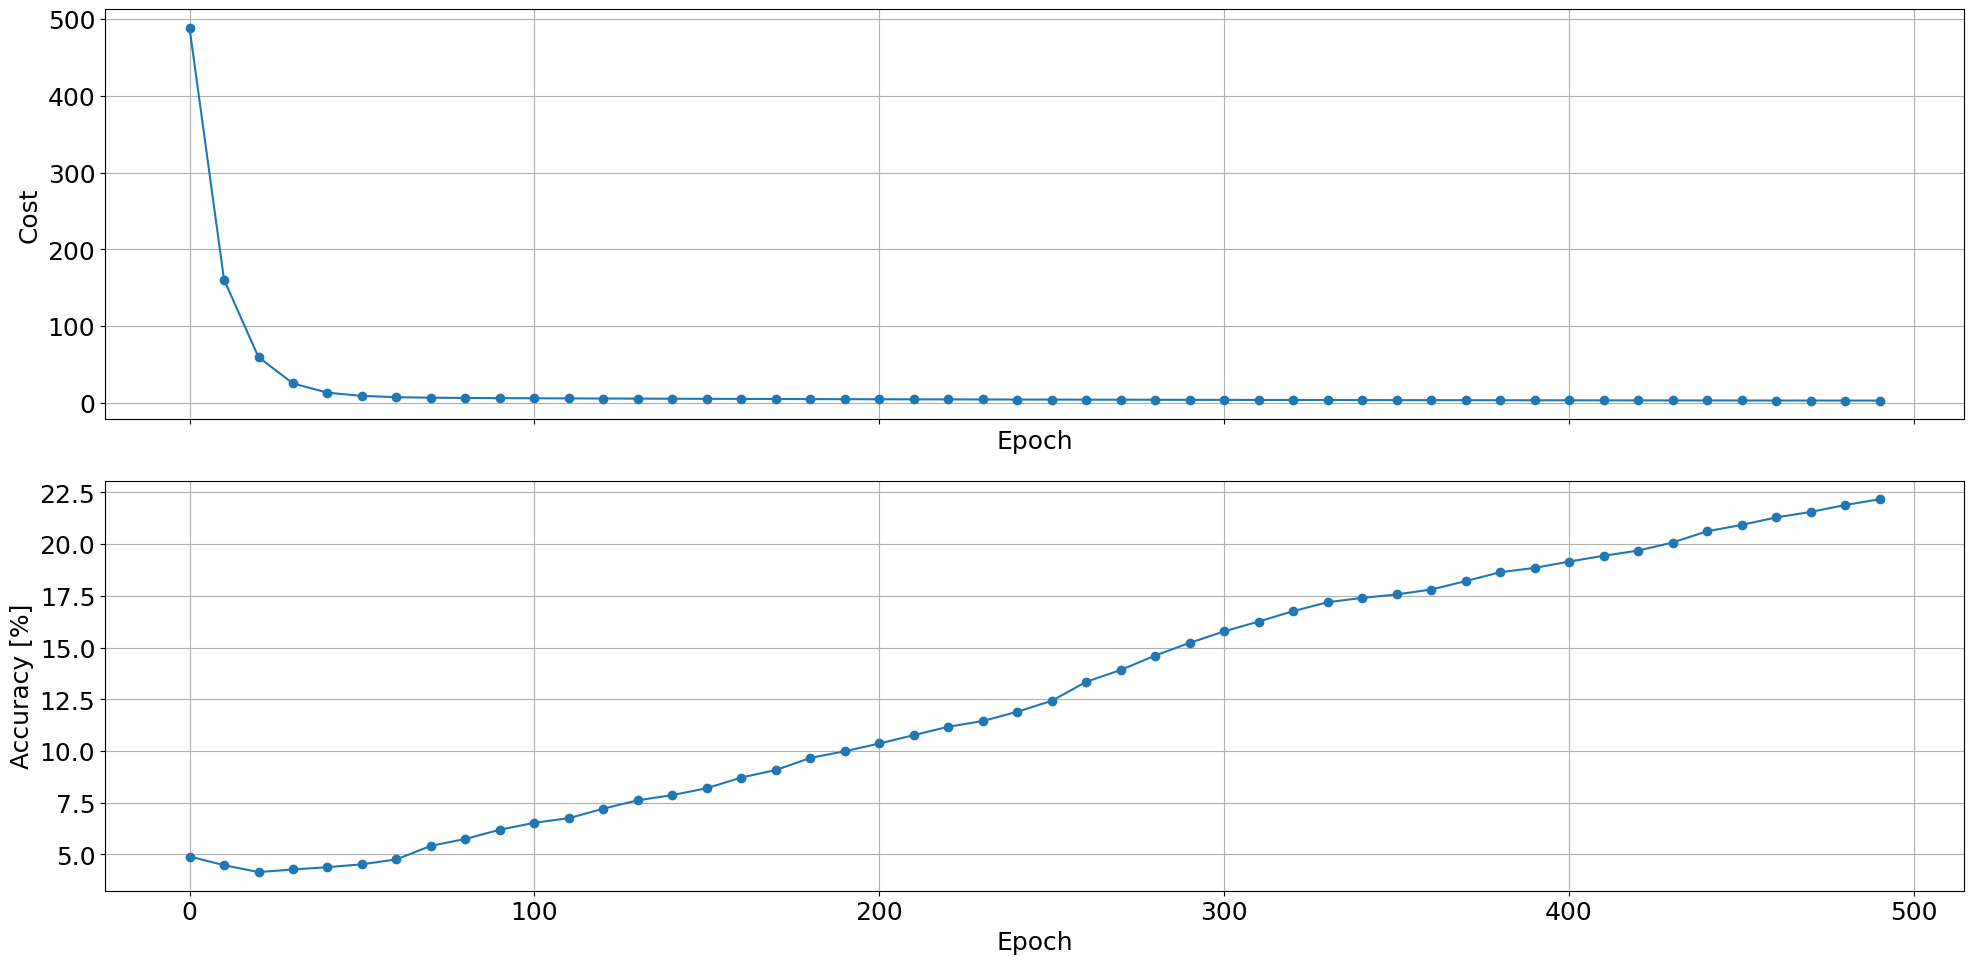

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

ax[0].plot(
    [epoch * 10 for epoch in range(len(values))],
    [value[0] for value in values],
    "o-"
)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Cost")
ax[0].grid()

ax[1].plot(
    [epoch * 10 for epoch in range(len(accuracies))],
    accuracies,
    "o-"
)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy [%]")
ax[1].grid()

plt.tight_layout()
plt.show()

## Testing the Multinomial Logistic Regression Model

We calculate the accuracy on the test set by counting how many predictions match the true labels and expressing the result as a percentage.

In [22]:
# Calculate accuracy on the test set

y_hat_test: np.ndarray = softmax(test_x_ext, theta)

pred: np.ndarray = np.argmax(y_hat_test, axis=1)

actual: np.ndarray = np.argmax(test_y_all, axis=1)

equalities: int = np.sum(pred == actual)

print(
    "Test accuracy: %2.2f%%"
    % (equalities / test_y_all.shape[0] * 100)
)

Test accuracy: 22.42%


### Confusion Matrix

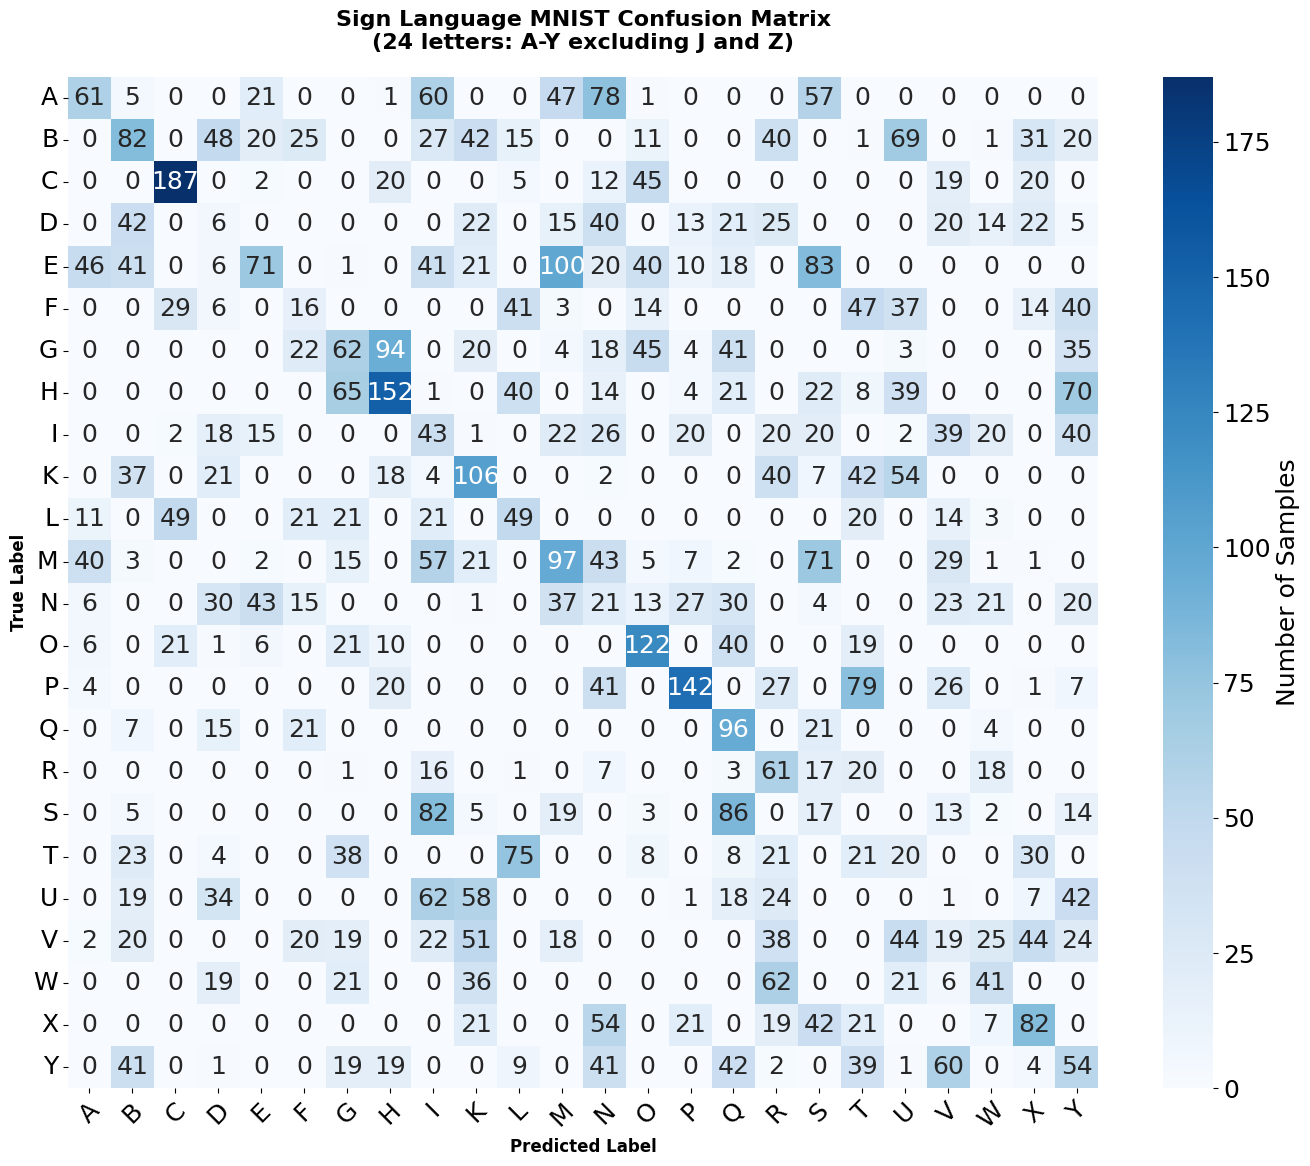

In [23]:
from sklearn.metrics import confusion_matrix

pred: np.ndarray = np.argmax(
    softmax(test_x_ext, theta),
    axis=1
)

actual: np.ndarray = np.argmax(test_y_all, axis=1)

classes: list[str] = list(labels_map.values())

cm: np.ndarray = confusion_matrix(
    actual,
    pred,
    labels=np.arange(k)
)

assert cm.shape == (k, k)
assert cm.sum() == test_y_all.shape[0]

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    cbar_kws={"label": "Number of Samples"}
)

plt.title(
    "Sign Language MNIST Confusion Matrix\n"
    "(24 letters: A-Y excluding J and Z)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Predicted Label", fontsize=12, fontweight="bold")
plt.ylabel("True Label", fontsize=12, fontweight="bold")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()